# Notebook 1: Generación del Dataset mediante Etiquetado Automático

Este notebook contiene el pipeline para la extracción y clasificación automática de fragmentos de artículos científicos en español. La solución utiliza un enfoque basado en reglas (Expresiones Regulares) enriquecidas para identificar las secciones retóricas del texto.

## Estructura de Datos de Salida
El proceso genera un archivo CSV con las siguientes columnas:
- `source_file`: Identificador único del documento original.
- `source_path`: path in the original source.
- `category`: Etiqueta asignada {INTRO, BACK, METH, RES, DISC, LIM, CONC, CONTR}
- `keywords`: Palabras claves.
- `key_phrases`: Frases cortas extraidas del snippet.
- `snippet`: Fragmento de texto extraído (longitud: 250 - 1000 palabras)
- `confidence`: {high, medium, low}


## 1. Configuración del Entorno e Importaciones
En esta sección se cargan las librerías necesarias para el procesamiento de texto, análisis de datos y visualización de resultados.

In [1]:
import os
import re
import csv
import io
import pandas as pd
from collections import Counter
import random

# Visualización y análisis
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Google Colab y Google Drive API
from google.colab import auth
from google.auth import default
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload

print("Librerías cargadas exitosamente.")


Librerías cargadas exitosamente.


## 2. Autenticación y Conexión con Google Drive
Debido al volumen del corpus (más de 1.8 millones de archivos), utilizamos la API de Google Drive directamente para optimizar la velocidad de descarga y evitar latencias del sistema de archivos de Colab.

In [2]:
# Autenticación de la cuenta de Google
auth.authenticate_user()
creds, _ = default()

# Construcción del cliente del servicio Drive v3
drive_service = build('drive', 'v3', credentials=creds)
print("Conexión exitosa con Google Drive API.")

Conexión exitosa con Google Drive API.


## 3. Definición de Rutas y Gestión de Archivos

Para garantizar la integridad del experimento y evitar el Data Leakage, mantenemos un registro de los archivos que ya han sido procesados manualmente o en baches (batches) anteriores

In [3]:
# --- Rutas de Archivos Locales y de Validación ---
unified_csv = './etiquetas_manuales_unificadas.csv'
full_contr_csv = './validacion_CONTR_edwin(2374).csv'

# --- Gestión de Baches de Autoetiquetado ---
# Lista de baches anteriores para evitar duplicidad y contaminación
previous_labeled_csvs = [
    './auto_labeled_output.csv',
    './auto_labeled_output_batch2.csv',
    './auto_labeled_output_batch3.csv',
    './auto_labeled_output_batch4.csv'
]

NEW_BATCH_NAME = 'auto_labeled_output_batch5.csv'
FINAL_AUTOLABELED_CSV = 'final_auto_labeled_output.csv'

# ID de la carpeta compartida en Google Drive que contiene el corpus (.txt)
SHARED_FOLDER_ID = '1v90N8M6Ld3a76hlNXyQw7jhpX_fqY3Yc'

print(f"Configuración de rutas completada. Preparado para generar: {NEW_BATCH_NAME}")

Configuración de rutas completada. Preparado para generar: auto_labeled_output_batch5.csv


## 4. Consolidación de Datos Autoetiquetados

Para evitar el procesamiento redundante y asegurar que el modelo final se entrene con un conjunto de datos único, consolidamos todos los fragmentos generados en iteraciones anteriores. Aplicamos una deduplicación estricta basada en el contenido del fragmento (snippet).

In [5]:
# Consolidación de DataFrames autoetiquetados previamente
previous_auto_labeled_df = pd.DataFrame()

for file in previous_labeled_csvs:
    try:
        df_temp = pd.read_csv(file)
        print(f"Reading file: {file}. Shape {df_temp.shape}")
        previous_auto_labeled_df = pd.concat([previous_auto_labeled_df, df_temp])
    except FileNotFoundError:
        print(f"Aviso: El bache {file} no existe aún, se omitirá.")

print(f"\nTotal antes de deduplicación: {previous_auto_labeled_df.shape[0]}")
previous_auto_labeled_df.drop_duplicates(inplace=True)
print(f"Total después de deduplicación: {previous_auto_labeled_df.shape[0]}")

print("Vista previa del acumulado")
previous_auto_labeled_df.head()

Reading file: ./auto_labeled_output.csv. Shape (3911, 6)
Reading file: ./auto_labeled_output_batch2.csv. Shape (15117, 6)
Reading file: ./auto_labeled_output_batch3.csv. Shape (7155, 6)
Reading file: ./auto_labeled_output_batch4.csv. Shape (2571, 6)

Total antes de deduplicación: 28754
Total después de deduplicación: 28754
Vista previa del acumulado


,source_file,category,snippet,word_count,matched_keywords,regex_score
0,166702193.txt,METH,UNIVERSIDAD JOSÉ CARLOS MARIÁTEGUI VICERRECTOR...,1000,"procedimiento, procedimientos, metodología",11
1,109231260.txt,INTRO,TRABAJO FIN DE GRADO: COMPETENCIA EN EL SECTO...,992,"introducción, objetivos",5
2,109231260.txt,METH,Lucha contra el dopaje: Para evitar dicha prác...,998,"encuesta, muestra",5
3,109231260.txt,RES,Tabla 8. Porcentaje de actividad deportiva por...,996,"en la figura, en la tabla",3
4,109231260.txt,LIM,"personas mayores. Por eso, los socios que desd...",987,falta de,2


# Autoclasificación de Segmentos

## 5. Análisis del "Gold Standard" para Descubrimiento de Patrones

Antes de construir las reglas de clasificación (Regex), realizamos un Análisis Exploratorio de Datos (EDA) sobre el dataset de etiquetas manuales. El objetivo es identificar los términos y frases con mayor poder discriminatorio para cada sección retórica.

### 5.1 Extracción de Términos Frecuentes por Categoría
Utilizamos las columnas keywords y key_phrases asignadas manualmente para refinar nuestros patrones de búsqueda.

In [6]:
def obtener_top_terminos(df_subset, nombre_columna, top_n=20):
    """Extrae y cuenta las frecuencias de términos en una columna delimitada."""
    todos_los_terminos = []

    # Recorrer cada fila de la columna especificada (ej. 'keywords')
    for texto in df_subset[nombre_columna].dropna():
        # Separar por comas o puntos y comas
        terminos = re.split(r'[,;]', str(texto))
        # Limpiar espacios en blanco y convertir a minúsculas
        todos_los_terminos.extend([t.strip().lower() for t in terminos if t.strip()])

    # Contar las frecuencias y devolver los N más comunes
    return Counter(todos_los_terminos).most_common(top_n)


# Análisis por cada categoría detectada en el Gold Standard
df_manual = pd.read_csv(unified_csv)
print(f"Tamaño del dataframe etiquetado manualmente {df_manual.shape}")

# Analizar automáticamente todas las categorías que existan en el CSV
categorias_encontradas = df_manual['category'].unique()
print(f"\nCategorías detectadas en el archivo: {categorias_encontradas}")

# Diccionarios para guardar los resultados
resultados_keywords = {}
resultados_frases = {}

for categoria in categorias_encontradas:
    # Filtrar el dataframe por la categoría actual
    df_categoria = df_manual[df_manual['category'] == categoria]

    print(f"\n{'='*40}")
    print(f"ANÁLISIS PARA LA CATEGORÍA: {categoria} (Muestras: {len(df_categoria)})")
    print(f"{'='*40}")

    # Analizar la columna 'keywords'
    top_keywords = obtener_top_terminos(df_categoria, 'keywords', top_n=15)
    print("\n--- Top 15 Keywords ---")
    for termino, frecuencia in top_keywords:
        print(f" - {termino}: {frecuencia} veces")

    # Analizar la columna 'key_phrases' (si existe en el CSV)
    if 'key_phrases' in df_manual.columns:
        top_phrases = obtener_top_terminos(df_categoria, 'key_phrases', top_n=10)
        print("\n--- Top 10 Key Phrases ---")
        for frase, frecuencia in top_phrases:
            print(f" - {frase}: {frecuencia} veces")

Tamaño del dataframe etiquetado manualmente (1601, 7)

Categorías detectadas en el archivo: ['CONC' 'CONTR' 'LIM' 'INTRO' 'BACK' 'DISC' 'RES' 'METH']

ANÁLISIS PARA LA CATEGORÍA: CONC (Muestras: 200)

--- Top 15 Keywords ---
 - conclusiones: 28 veces
 - trabajo futuro: 18 veces
 - estudio: 11 veces
 - investigación: 10 veces
 - trabajo: 6 veces
 - estudiante: 5 veces
 - social: 4 veces
 - calidad: 4 veces
 - información: 4 veces
 - comunicación: 4 veces
 - educación: 4 veces
 - resultados: 4 veces
 - formación: 4 veces
 - crecimiento: 4 veces
 - recomendaciones: 4 veces

--- Top 10 Key Phrases ---
 - finalmente: 3 veces
 - presente trabajo: 2 veces
 - conclusiones: 2 veces
 - una transformación cultural: 1 veces
 - productos software de calidad de acuerdo con los requisitos: 1 veces
 - la transformación digital: 1 veces
 - como: integración continua: 1 veces
 - entrega continua: 1 veces
 - tratamiento quirúrgico: 1 veces
 - turf toe: 1 veces

ANÁLISIS PARA LA CATEGORÍA: CONTR (Muestras

## Clasificación Heurística (Construcción de Regex)

En esta fase, traducimos los hallazgos del análisis de frecuencias en expresiones regulares complejas. Para optimizar la clasificación, implementamos tres componentes críticos:

1. Segmentación Semántica: División de documentos en ventanas de 250 a 1000 palabras para mantener la coherencia temática.

2. Umbrales Dinámicos (Thresholds): Ajuste de la sensibilidad por clase para mitigar el desbalance (específicamente para fortalecer las clases menos representadas).

3. Filtro de Estructura Académica: Validación previa de la formalidad del documento para reducir ruido de textos no estructurados.

In [ ]:
# ==========================================
# 1. CONFIGURACIÓN Y REGLAS DE AISLAMIENTO
# ==========================================

# Set to a small number (e.g., 10) for testing, then change to 2000 for the full run.
MIN_SNIPPETS_PER_CLASS = 1800
THRESHOLDS = {
    "DISC": 2,   # Mantenemos el mínimo para facilitar la recolección
    "CONC": 2,
    "INTRO": 3,  # altamente representada
    "LIM": 2,
    "BACK": 3,   # Subimos a 3 por el ruido de citaciones "et al."
    "METH": 4,   # Subimos a 4 porque tiene el score más alto (6.0) y ya superó la meta
    "RES": 4     # Subimos a 4 para reducir falsos positivos y canibalización
}
DEFAULT_THRESHOLD = 2
MIN_WORDS = 250
MAX_WORDS = 750

# Cargar los IDs que ya etiquetaste manualmente para IGNORARLOS en el autoetiquetado
# Esto asegura el cumplimiento de la regla de particionamiento estricto del documento.
df_validated = pd.read_csv(unified_csv)
manually_labeled_files = set(df_validated['source_file'].unique())

full_contr = pd.read_csv(full_contr_csv)
other_contr_files = set(full_contr['source_file'].unique()) - manually_labeled_files

previous_files = set(previous_auto_labeled_df['source_file'].unique())

ids_to_exclude = manually_labeled_files | other_contr_files | previous_files
print(f"IDs to exclude: {len(ids_to_exclude)}")

# 2. Define the patterns (Spanish keywords since the text is in Spanish)
regex_patterns = {
    "INTRO": re.compile(
        r'\b('
        r'objetivo\sgeneral|objetivo\sprincipal|el\sobjetivo\sde\s(?:este|esta)|'
        r'problema\sde\sinvestigaci[oó]n|introducci[oó]n|justificaci[oó]n|'
        r'prop[oó]sito\sprincipal|planteamiento\sdel\sproblema|'
        r'el\spresente\strabajo\s(?:aborda|tiene\scomo|se\scentra)|'
        r'la\sfinalidad\sde\s(?:este|esta)|hip[oó]tesis\sde\strabajo'
        r')\b',
        re.IGNORECASE
    ),
    "BACK": re.compile(
        r'\b('
        r'antecedentes|estado\sdel\sarte|trabajos\sprevios|'
        r'marco\ste[oó]rico|estudios\sprevios|investigaciones\sprevias|'
        r'revisi[oó]n\sbibliogr[aá]fica|literatura\scient[ií]fica|'
        r'trabajo\srelacionado|et\sal\.|seg[uú]n\s[A-Z][a-z]+|'
        r'estudios\santeriores|tradicionalmente'
        r')\b',
        re.IGNORECASE
    ),
    "METH": re.compile(
        r'\b('
        r'metodolog[íi]a|dise[ñn]o\smetodol[oó]gico|dise[ñn]o\sde\sinvestigaci[oó]n|'
        r'materiales\sy\sm[eé]todos|material\sy\sm[eé]todo|'
        r'poblaci[oó]n\sy\smuestra|tama[ñn]o\sde\s(?:la\s)?muestra|'
        r'criterios\sde\sinclusi[oó]n|criterios\sde\sexclusi[oó]n|'
        r'instrumentos\sde\srecolecci[oó]n|recolecci[oó]n\sde\sdatos|'
        r'an[aá]lisis\sestad[íi]stico|procedimiento\sexperimental|'
        r'enfoque\scuantitativo|enfoque\scualitativo|'
        r'investigaci[oó]n\s(?:cualitativa|cuantitativa)|'
        r'entrevistas\ssemiestructuradas|aplicaci[oó]n\sde\scuestionarios|'
        r'variables\sdependientes|variables\sindependientes'
        r')\b',
        re.IGNORECASE
    ),
    "RES": re.compile(
        r'\b('
        # Marcadores de sección y frases de apertura
        r'resultados|hallazgos|los\sresultados\smuestran|los\sresultados\sindican|'
        r'los\sresultados\sobtenidos|los\sdatos\smuestran|los\sanálisis\smuestran|'
        r'el\sanálisis\sindica|el\sanálisis\sreveló|'

        # Verbos de hallazgo en pasado (núcleo del reporte empírico)
        r'se\sencontró\sque|se\sobservó\sque|se\sidentificó|se\sdetectó|'
        r'se\sevidenció|se\sregistró|se\sobtuvieron|se\spudo\sobservar|'
        r'se\sapreció|arrojó|reveló|mostró|evidenció|'

        # Referencias a elementos visuales/tabulares
        r'como\sse\smuestra\sen|como\sse\sobserva\sen|como\sse\saprecia\sen|'
        r'en\sla\sfigura|en\sel\sgráfico|en\sla\stabla|en\sel\scuadro|'
        r'tal\scomo\sse\smuestra|véase\sla\sfigura|véase\sla\stabla|'

        # Lenguaje estadístico cuantitativo
        r'estadísticamente\ssignificativo|diferencia\ssignificativa|'
        r'no\ssignificativo|correlación\spositiva|correlación\snegativa|'
        r'valor\sde\sp|p\s[<>≤≥]\s0\.|intervalo\sde\sconfianza|'
        r'desviación\sestándar|error\sestándar|media\sde|mediana\sde|'
        r'coeficiente\sde|odds\sratio|razón\sde|frecuencia\srelativa|'

        # Cuantificaciones comparativas
        r'un\saumento\sde|una\sreducción\sde|una\sdisminución\sde|'
        r'superior\sa|inferior\sa|mayor\sque|menor\sque|'
        r'el\s\d+\s?%\sde|un\s\d+\s?%|aproximadamente\sel|'
        r'los\sresultados\sobtuvieron|los\sparticipantes\sreportaron'
        r')\b',
        re.IGNORECASE
    ),
    "DISC": re.compile(
        r'\b('
        # Marcadores de sección y frases de apertura
        r'discusi[oó]n|interpretaci[oó]n\sde\slos\sresultados|an[aá]lisis\scr[ií]tico|'

        # Comparación con literatura previa (Clave para DISC)
        r'en\sconcordancia\scon|coincide\scon|consistente\scon|'
        r'similar\sa\slo\sreportado|en\sl[ií]nea\scon|est[aá]\sde\sacuerdo\scon|'
        r'a\sdiferencia\sde|en\scontraste\scon|difiere\sde|contrario\sa|'
        r'mientras\sque\sotros\sautores|comparado\scon\sel\sestudio\sde|'

        # Evaluación y significado de los hallazgos
        r'estos\sresultados\ssugieren|estos\shallazgos|'
        r'esto\simplica\sque|esto\sindica\sque|lo\santerior\ssugiere|'
        r'apoya\sla\ship[oó]tesis|valida\snuestro\senfoque|corrobora\sque|'
        r'permite\sinferir|se\sinterpreta\scomo|da\scuenta\sde|'

        # Explicación de causas e incertidumbre
        r'esto\sse\sdebe\sa|podr[ií]a\sexplicarse\spor|atribuible\sa|'
        r'es\sposible\sque|podr[ií]a\sdeberse\sa|una\sposible\sexplicaci[oó]n|'
        r'probablemente\sdebido\sa|factores\sque\sinfluyeron|'
        r'a\sla\sluz\sde|bajo\sesta\sperspectiva|nos\slleva\sa\spensar|'

        # Implicaciones y relevancia
        r'relevancia\spara|impacto\sen|consecuencia\sde|'
        r'abre\snuevas\sperspectivas|demuestra\sla\simportancia\sde'
        r')\b',
        re.IGNORECASE
    ),
    # "CONTR": re.compile(r'\b(contribución|este\strabajo\saporta|nuestro\senfoque|se\spropone\sun\snuevo)\b', re.IGNORECASE),
    "LIM": re.compile(
        r'\b('
        r'limitaci[oó]n|limitaciones|no\sfue\sposible|no\ses\sposible|'
        r'sesgos\spotenciales|no\sse\spuede|sesgo|sesgado|sesgada|se\sdesconoce|imposibilidad|'
        r'no\spermite|no\spermite\sgeneralizar|fuera\sdel\salcance|no\sse\spudo|no\sse\spretende|'
        r'restricci[oó]n|restringe\sla|no\sgeneraliz|no\srepresenta|tama[ñn]o\sde\sla\smuestra|'
        r'tama[ñn]o\smuestral|muestra\speque[ñn]a|futuras\sinvestigaciones|'
        r'futuras\sl[íi]neas|l[íi]neas\sfuturas|investigaci[oó]n\sfutura|'
        r'trabajo\sfuturo|queda\spendiente|falta\sde|carencia\sde|'
        r'no\sse\sdispone|pese\sa\sno\scontar|sin\scontar\scon|'
        r'no\sabarca|no\sincluye|no\scontempla|ciertas\slimitaciones|'
        r'estas\slimitaciones|dificulta|dificultades\sy\slimitaciones|debe\sinterpretarse\scon\scautela|'
        r'dise[ñn]o\stransversal\sno\spermite'
        r')\b',
        re.IGNORECASE
    ),
    "CONC": re.compile(

        r'\b('
        # Marcadores de sección explícitos
        r'conclusiones|conclusi[oó]n|en\sconclusi[oó]n|a\smodo\sde\sconclusi[oó]n|'
        r'para\sconcluir|como\sconclusi[oó]n|a\st[íi]tulo\sde\sconclusi[oó]n|'

        # Verbos y frases de cierre epistémico
        r'se\sconcluye\sque|podemos\sconcluir|cabe\sconcluir|'
        r'es\sposible\sconcluir|permite\sconcluir|lleva\sa\sconcluir|'
        r'los\sresultados\spermiten\sconcluir|los\shallazgos\spermiten\sconcluir|'

        # Síntesis y resumen (más fuerte que un simple "en resumen")
        r'en\sresumen|en\ss[íi]ntesis|en\sdefinitiva|en\s[uú]ltima\sinstancia|'
        r'implicaciones\spr[aá]cticas|como\sreflexi[oó]n\sfinal|'
        r'en\sconjunto[,\s]|tomados\sen\sconjunto|globalmente[,\s]|'
        r'en\sglobal|en\st[ée]rminos\sgenerales[,\s]|'

        # Afirmaciones de cierre sobre el estudio
        r'este\sestudio\sha\sdemostrado|este\strabajo\sha\sdemostrado|'
        r'esta\sinvestigaci[oó]n\sha\sconfirmado|este\sestudio\sconfirma|'
        r'este\strabajo\saporta\sevidencia|se\sha\sdemostrado\sque|'
        r'se\sha\scomprobado\sque|se\sha\sevidenciado\sque|'
        r'los\sresultados\sobtenidos\sconfirman|'

        # Prospectiva (recomendaciones y trabajo futuro — complementa a LIM)
        r'se\srecomienda|se\ssugiere\sque|futuras\sinvestigaciones\sdeber[íi]a|'
        r'pr[oó]ximas\sinvestigaciones|estudios\sfuturos\sdeber[íi]a|'
        r'es\snecesario\scontinua|queda\spendiente\spara\sfuturas|'
        r'finalmente[,\s]'
        r')\b',
        re.IGNORECASE
    ),
}

IDs to exclude: 15132


In [ ]:
# ==========================================
# FUNCIONES CORE
# ==========================================

def segment_text(text, min_words=250, max_words=1000):
    """
    Divides the text into length-controlled snippets,
    accumulating paragraphs to maintain semantic coherence.
    """
    paragraphs = text.split('\n')
    snippets = []
    current_snippet = []
    words_count = 0

    for p in paragraphs:
        paragraph_words = p.split()
        p_words = len(paragraph_words)

        if p_words == 0:
            continue

        # If adding the paragraph keeps the snippet within the max limit
        if words_count + p_words <= max_words:
            current_snippet.append(p)
            words_count += p_words
        else:
            # If it exceeds the max, save what we have if it meets the minimum
            if words_count >= min_words:
                snippets.append(" ".join(current_snippet).strip())

            # Start a new snippet
            # If the current paragraph ALONE exceeds max_words (e.g., bad PDF extraction),
            # we truncate it so we don't lose the data or break the project rules.
            if p_words > max_words:
                truncated_p = " ".join(paragraph_words[:max_words])
                snippets.append(truncated_p)
                current_snippet = []
                words_count = 0
            else:
                current_snippet = [p]
                words_count = p_words

    # Validate the remainder at the end of the loop
    if min_words <= words_count <= max_words:
        snippets.append(" ".join(current_snippet).strip())

    return snippets


def classify_snippet_detailed(snippet, regex_patterns, thresholds=None):
    """
    Returns the category, the score, and the exact words that matched.
    """
    active_thresholds = thresholds if thresholds else THRESHOLDS
    scores = {}
    matches_dict = {}

    for category, pattern in regex_patterns.items():
        matches = pattern.findall(snippet)

        # Min threshold per category
        min_required = active_thresholds.get(category, DEFAULT_THRESHOLD)

        if len(matches) >= min_required:
            scores[category] = len(matches)
            # Handle both strings and tuples returned by regex findall
            clean_words = [m.lower() if isinstance(m, str) else m[0].lower() for m in matches]
            matches_dict[category] = list(set(clean_words)) # Remove duplicates

    if scores:
        best_category = max(scores, key=scores.get)
        return best_category, scores[best_category], matches_dict[best_category]

    return None, 0, []

# ==========================================
# DIRECTORY EXECUTION (VIA GOOGLE DRIVE API)
# ==========================================

def download_file_content(drive_service, file_id):
    """Downloads a text file directly into memory from Google Drive."""
    request = drive_service.files().get_media(fileId=file_id)
    fh = io.BytesIO()
    downloader = MediaIoBaseDownload(fh, request)
    done = False
    while done is False:
        status, done = downloader.next_chunk()
    return fh.getvalue().decode('utf-8')


def is_formal_structure(text):
    """
    Heurística rápida para descartar textos no académicos (entrevistas, blogs, etc.)
    sin segmentar todo el archivo.
    """
    # Revisamos solo el inicio del documento para eficiencia (primeros 2000 caracteres)
    header_sample = text[:2000].lower()

    # Palabras clave que suelen aparecer en la estructura formal de artículos o tesis
    academic_anchors = [
        'resumen', 'abstract', 'introducción', 'bibliografía',
        'conclusiones', 'universidad', 'facultad', 'doi:', 'issn'
    ]

    # Contamos cuántas anclas encontramos
    matches = sum(1 for anchor in academic_anchors if anchor in header_sample)

    # Si encuentra al menos 2, asumimos que tiene estructura mínima académica
    return matches >= 2


def auto_label_drive_api(folder_id, output_csv, files_to_exclude, regex_patterns):
    """
    Reads files from a massive shared Google Drive folder using the Drive API
    to completely bypass Colab's FUSE timeout errors.
    """
    results = []
    category_counts = {cat: 0 for cat in regex_patterns.keys()}
    files_processed = 0

    print("Querying Google Drive API...")

    # Emulate random sorting in Google Drive
    # order_options = ['name desc', 'name asc', 'createdTime desc', 'modifiedTime desc']

    page_token = None
    early_stop = False

    try:
        while not early_stop:
            try:
                # Query the API: "Give me up to 1000 .txt files inside this specific folder"
                # We use name contains '.txt' to filter quickly on Google's servers
                response = drive_service.files().list(
                    q=f"'{folder_id}' in parents and name contains '.txt' and trashed = false",
                    spaces='drive',
                    fields='nextPageToken, files(id, name)',
                    pageSize=1000,
                    pageToken=page_token,
                    orderBy='createdTime asc'  #random.choice(order_options)
                ).execute()

                files = response.get('files', [])

                if not files:
                    print("No more files found in the folder.")
                    break

                # IMPROVEMENT1: LOCAL RANDOMNESS ---
                random.shuffle(files)

                for file_item in files:
                    # 1. Check Early Stopping Condition
                    if all(count >= MIN_SNIPPETS_PER_CLASS for count in category_counts.values()):
                        print(f"\n[SUCCESS] Early stopping triggered! All categories have at least {MIN_SNIPPETS_PER_CLASS} snippets.")
                        early_stop = True
                        break

                    filename = file_item.get('name')
                    file_id = file_item.get('id')

                    # 2. Skip if already labeled
                    if filename in files_to_exclude:
                        continue

                    try:
                        # 3. Download the text directly into memory
                        text = download_file_content(drive_service, file_id)

                        # ---IMPROVEMENT 2: FILTER FOR FORMAL TEXT ---
                        if not is_formal_structure(text):
                            # Unstructured text is skipped
                            continue

                        # 4. Run your exact NLP pipeline
                        snippets = segment_text(text, min_words=MIN_WORDS, max_words=MAX_WORDS)
                        best_snippets_per_file = {}

                        for snippet in snippets:
                            category, score, found_keywords = classify_snippet_detailed(snippet, regex_patterns, thresholds=THRESHOLDS)

                            if category:
                                if category not in best_snippets_per_file or score > best_snippets_per_file[category]['regex_score']:
                                    best_snippets_per_file[category] = {
                                        'source_file': filename,
                                        'category': category,
                                        'snippet': snippet,
                                        'word_count': len(snippet.split()),
                                        'matched_keywords': ", ".join(found_keywords),
                                        'regex_score': score
                                    }

                        # 5. Add to results and update the tracker
                        for cat, data in best_snippets_per_file.items():
                            results.append(data)
                            category_counts[cat] += 1

                        files_processed += 1

                        if files_processed % 50 == 0:
                            print(f"Processed {files_processed} files... Current counts: {category_counts}")

                    except Exception as e:
                        print(f"Error processing {filename}: {e}")

                # Get the token for the next 1000 files
                page_token = response.get('nextPageToken', None)
                if page_token is None:
                    break # We reached the end of the folder

            except Exception as e:
                print(f"API Error occurred: {e}")
                break

    except KeyboardInterrupt:
        print("\n\n[!] Execution interrupted manually by the user.")
        print("[!] Stopping safely and preparing to save collected data...")

    # Save results
    if results:
        df_results = pd.DataFrame(results)
        df_results.to_csv(output_csv, index=False, encoding='utf-8')

        print("\n--- FINAL CATEGORY DISTRIBUTION ---")
        print(df_results['category'].value_counts())
        print(f"Done! Generated {len(df_results)} snippets from {df_results.source_file.nunique()} files.")
        return df_results
    else:
        print("No snippets were generated.")
        return pd.DataFrame()

# ==========================================
# EXECUTION
# ==========================================
new_auto_labeled_df = auto_label_drive_api(
    folder_id=SHARED_FOLDER_ID,
    output_csv=NEW_BATCH_NAME,
    files_to_exclude=ids_to_exclude,
    regex_patterns=regex_patterns
)

Querying Google Drive API...


Processed 50 files... Current counts: {'INTRO': 3, 'BACK': 1, 'METH': 3, 'RES': 6, 'DISC': 4, 'LIM': 6, 'CONC': 3}
Processed 100 files... Current counts: {'INTRO': 7, 'BACK': 8, 'METH': 7, 'RES': 11, 'DISC': 9, 'LIM': 10, 'CONC': 9}
Processed 150 files... Current counts: {'INTRO': 9, 'BACK': 9, 'METH': 10, 'RES': 17, 'DISC': 12, 'LIM': 12, 'CONC': 15}
Processed 200 files... Current counts: {'INTRO': 15, 'BACK': 16, 'METH': 13, 'RES': 22, 'DISC': 16, 'LIM': 17, 'CONC': 21}
Processed 250 files... Current counts: {'INTRO': 21, 'BACK': 20, 'METH': 14, 'RES': 25, 'DISC': 23, 'LIM': 21, 'CONC': 30}
Processed 300 files... Current counts: {'INTRO': 25, 'BACK': 24, 'METH': 16, 'RES': 32, 'DISC': 26, 'LIM': 28, 'CONC': 35}
Processed 350 files... Current counts: {'INTRO': 27, 'BACK': 28, 'METH': 19, 'RES': 37, 'DISC': 29, 'LIM': 33, 'CONC': 42}
Processed 400 files... Current counts: {'INTRO': 29, 'BACK': 35, 'METH': 21, 'RES': 42, 'DISC': 30, 'LIM': 37, 'CONC': 49}
Processed 450 files... Current 

Processed 2350 files... Current counts: {'INTRO': 196, 'BACK': 189, 'METH': 127, 'RES': 251, 'DISC': 158, 'LIM': 196, 'CONC': 258}
Processed 2400 files... Current counts: {'INTRO': 202, 'BACK': 194, 'METH': 129, 'RES': 256, 'DISC': 161, 'LIM': 200, 'CONC': 266}
Processed 2450 files... Current counts: {'INTRO': 206, 'BACK': 199, 'METH': 129, 'RES': 262, 'DISC': 166, 'LIM': 202, 'CONC': 272}
Processed 2500 files... Current counts: {'INTRO': 210, 'BACK': 204, 'METH': 133, 'RES': 268, 'DISC': 170, 'LIM': 204, 'CONC': 277}
Processed 2550 files... Current counts: {'INTRO': 216, 'BACK': 207, 'METH': 136, 'RES': 273, 'DISC': 171, 'LIM': 208, 'CONC': 282}
Processed 2600 files... Current counts: {'INTRO': 226, 'BACK': 212, 'METH': 143, 'RES': 285, 'DISC': 177, 'LIM': 215, 'CONC': 289}
Processed 2650 files... Current counts: {'INTRO': 236, 'BACK': 220, 'METH': 145, 'RES': 287, 'DISC': 183, 'LIM': 218, 'CONC': 293}
Processed 2700 files... Current counts: {'INTRO': 245, 'BACK': 227, 'METH': 150, 'R

## Consolidando Archivos autoetiquetados

In [12]:
# Concatenating the previous and new dataframes
if new_auto_labeled_df.empty:
    print("No new auto-labeled data to concatenate.")
    final_auto_labeled_df = previous_auto_labeled_df
else:
    final_auto_labeled_df = pd.concat([previous_auto_labeled_df, new_auto_labeled_df])

print(f"Final Auto labeled df {final_auto_labeled_df.shape}")
final_auto_labeled_df.to_csv(FINAL_AUTOLABELED_CSV, index=False, encoding='utf-8')
print(f"Final file saved as {FINAL_AUTOLABELED_CSV}")


No new auto-labeled data to concatenate.
Final Auto labeled df (28754, 6)
Final file saved as final_auto_labeled_output.csv


## Análisis Exploratorio de Datos

Tras la ejecución del pipeline de etiquetado automático, esta sección permite auditar la calidad del dataset generado. El objetivo principal es garantizar que los fragmentos recolectados cumplan con las restricciones de diseño y posean la calidad semántica necesaria para el entrenamiento posterior de modelos de lenguaje (SciBETO).

### Dimensiones de Evaluación
El análisis se centra en cuatro pilares críticos:

1. Equilibrio de Clases: Se busca alcanzar el objetivo de 2,000 muestras por categoría (incluyendo 200 del conjunto separado de prueba). Un dataset balanceado previene que el modelo desarrolle sesgos hacia las clases mayoritarias (como RES o BACK) y mejore su desempeño en clases subrepresentadas (como DISC).

2. Cumplimiento de Restricciones Estructurales: Validación estricta de la longitud de los fragmentos. Para este proyecto, cada snippet debe situarse entre las 250 y 1,000 palabras, garantizando suficiente contexto semántico sin exceder la capacidad de procesamiento de los encoders.

3. Confianza y Diversidad Léxica: Evaluación de los puntajes de coincidencia (regex_score) y los términos que disparan la clasificación. Se busca que las categorías no dependan de una única palabra clave (ej. que INTRO no sea detectada únicamente por la palabra "Introducción"), sino por un conjunto diverso de marcadores retóricos.

4. Desambiguación (Overlap): Un punto crítico es el análisis de intersección entre clases semánticamente cercanas, específicamente entre Resultados (RES) y Discusión (DISC). El EDA identifica si existen términos compartidos que puedan confundir al modelo durante el entrenamiento.

--- EDA REPORT ---
Successfully loaded dataset: 28754 total snippets.

1. CLASS DISTRIBUTION
------------------------------
category
RES      6388
INTRO    5400
BACK     4955
METH     3522
CONC     3441
LIM      3236
DISC     1812
Name: count, dtype: int64




/tmp/ipykernel_4916/2825508320.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='category', order=class_counts.index, palette='viridis')


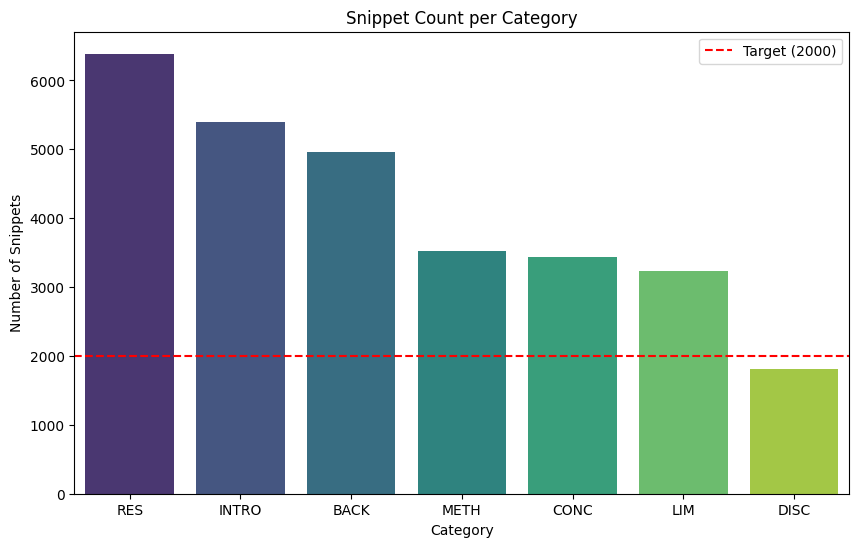


2. WORD COUNT CONSTRAINTS
------------------------------
count    28754.000000
mean       773.356820
std         94.534087
min        251.000000
25%        743.000000
50%        747.000000
75%        750.000000
max       1000.000000
Name: word_count, dtype: float64

SUCCESS: All snippets are strictly within the 250 - 1000 word limit.


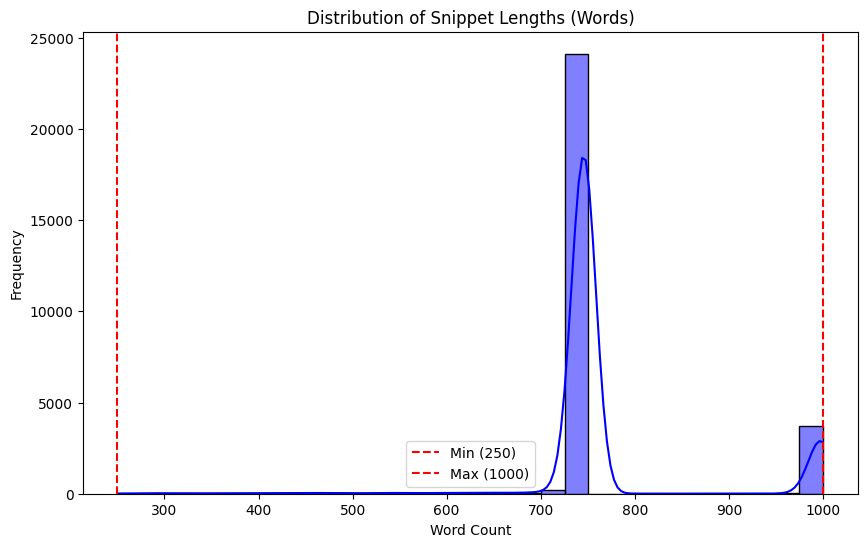


3. REGEX SCORE (CONFIDENCE)
------------------------------
category
BACK     3.34
CONC     2.72
DISC     2.66
INTRO    3.18
LIM      2.98
METH     5.86
RES      5.38
Name: regex_score, dtype: float64

4. WORD COUNT BY CATEGORY (Length Bias Check)
------------------------------


/tmp/ipykernel_4916/2825508320.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='word_count', palette='Set2')


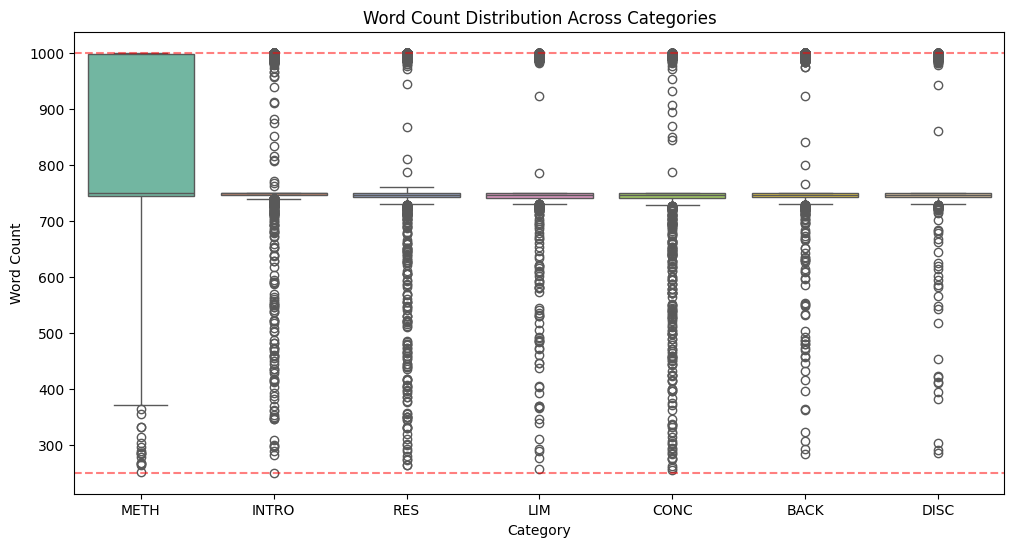


5. KEYWORD DIVERSITY
------------------------------

Top 5 triggers for METH:
  - 'metodología': 2195 times
  - 'muestra': 673 times
  - 'método': 520 times
  - 'diseño de investigación': 475 times
  - 'instrumentos': 444 times

Top 5 triggers for INTRO:
  - 'introducción': 4274 times
  - 'justificación': 1527 times
  - 'objetivo general': 928 times
  - 'objetivo': 787 times
  - 'objetivos': 599 times

Top 5 triggers for RES:
  - 'resultados': 5265 times
  - 'en la tabla': 1332 times
  - 'los resultados obtenidos': 1092 times
  - 'en la figura': 744 times
  - 'media de': 733 times

Top 5 triggers for LIM:
  - 'falta de': 1900 times
  - 'limitaciones': 852 times
  - 'limitación': 443 times
  - 'no se puede': 408 times
  - 'imposibilidad': 344 times

Top 5 triggers for CONC:
  - 'conclusiones': 1971 times
  - 'conclusión': 903 times
  - 'finalmente': 813 times
  - 'en definitiva': 536 times
  - 'se recomienda': 444 times

Top 5 triggers for BACK:
  - 'según el': 1603 times
  - 'según la

In [13]:
def run_eda(input_csv):
    """
    Performs Exploratory Data Analysis on the auto-labeled dataset
    to ensure it meets the project constraints before training.
    """
    try:
        df = pd.read_csv(input_csv)
        print(f"--- EDA REPORT ---")
        print(f"Successfully loaded dataset: {len(df)} total snippets.\n")
    except FileNotFoundError:
        print(f"Error: Could not find {input_csv}")
        return

    # CLASS BALANCE ANALYSIS
    print("1. CLASS DISTRIBUTION")
    print("-" * 30)
    class_counts = df['category'].value_counts()
    print(class_counts)
    print("\n")

    # Plot Class Distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='category', order=class_counts.index, palette='viridis')
    plt.title('Snippet Count per Category')
    plt.ylabel('Number of Snippets')
    plt.xlabel('Category')
    plt.axhline(y=2000, color='r', linestyle='--', label='Target (2000)')
    plt.legend()
    # plt.savefig('eda_class_distribution.png')
    # plt.close()
    # print("-> Saved class distribution plot as 'eda_class_distribution.png'")
    plt.show()

    # WORD COUNT CONSTRAINTS (Crucial for your project)
    print("\n2. WORD COUNT CONSTRAINTS")
    print("-" * 30)
    print(df['word_count'].describe())

    # Check for violations (below 250 or above 1000)
    violations = df[(df['word_count'] < 250) | (df['word_count'] > 1000)]
    if not violations.empty:
        print(f"\nWARNING: Found {len(violations)} snippets that violate the 250-1000 word limit!")
        print("Please check these source files:")
        print(violations[['source_file', 'category', 'word_count']].head())
    else:
        print("\nSUCCESS: All snippets are strictly within the 250 - 1000 word limit.")

    # Plot Word Count Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x='word_count', bins=30, kde=True, color='blue')
    plt.title('Distribution of Snippet Lengths (Words)')
    plt.xlabel('Word Count')
    plt.ylabel('Frequency')
    plt.axvline(x=250, color='r', linestyle='--', label='Min (250)')
    plt.axvline(x=1000, color='r', linestyle='--', label='Max (1000)')
    plt.legend()
    # plt.savefig('eda_word_count.png')
    # plt.close()
    # print("-> Saved word count distribution plot as 'eda_word_count.png'")
    plt.show()

    # REGEX CONFIDENCE (Are we matching enough words?)
    print("\n3. REGEX SCORE (CONFIDENCE)")
    print("-" * 30)
    avg_score_per_class = df.groupby('category')['regex_score'].mean().round(2)
    print(avg_score_per_class)

    # WORD COUNT BY CATEGORY (Checking for Length Bias)
    print("\n4. WORD COUNT BY CATEGORY (Length Bias Check)")
    print("-" * 30)
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='category', y='word_count', palette='Set2')
    plt.title('Word Count Distribution Across Categories')
    plt.ylabel('Word Count')
    plt.xlabel('Category')
    plt.axhline(y=250, color='r', linestyle='--', alpha=0.5)
    plt.axhline(y=1000, color='r', linestyle='--', alpha=0.5)
    plt.show()

    # KEYWORD DIVERSITY (What is triggering the regex?)
    print("\n5. KEYWORD DIVERSITY")
    print("-" * 30)
    for category in df['category'].unique():
        cat_df = df[df['category'] == category]
        all_kws = []
        for kw_string in cat_df['matched_keywords'].dropna():
            # Split by comma and clean
            kws = [k.strip() for k in kw_string.split(',') if k.strip()]
            all_kws.extend(kws)

        top_kws = Counter(all_kws).most_common(5)
        print(f"\nTop 5 triggers for {category}:")
        for kw, count in top_kws:
            print(f"  - '{kw}': {count} times")

    # keywords overlap between RES and DISC
    all_res_kws = set([k.strip() for kw_string in df[df['category'] == 'RES']['matched_keywords'].dropna()
                        for k in kw_string.split(',')])
    all_disc_kws = set([k.strip() for kw_string in df[df['category'] == 'DISC']['matched_keywords'].dropna()
                       for k in kw_string.split(',')])

    shared_kws = all_res_kws.intersection(all_disc_kws)
    print(f"\n[!] Keywords shared by RES and DISC: {shared_kws}")

    # DATA INTEGRITY (Duplicates & Nulls)
    print("\n6. DATA INTEGRITY CHECKS")
    print("-" * 30)

    # Check for empty snippets
    null_snippets = df['snippet'].isnull().sum()
    print(f"Null/Empty snippets: {null_snippets}")

    # Check for exact duplicate snippets (could happen if a PDF was read twice)
    duplicate_snippets = df.duplicated(subset=['snippet']).sum()
    print(f"Exact duplicate snippets: {duplicate_snippets}")
    if duplicate_snippets > 0:
        print("  -> Consider dropping duplicates: df.drop_duplicates(subset=['snippet'])")

    # Check for files that accidentally got assigned multiple categories
    # (Our script prevents this, but good to double check)
    files_with_multiple_cats = df.groupby('source_file')['category'].nunique()
    multi_cat_files = files_with_multiple_cats[files_with_multiple_cats > 1].count()
    print(f"Files contributing to more than one category: {multi_cat_files} (Should ideally be low/zero for strict separation)")

    # QUICK AUDIT
    print("\n7. QUICK AUDIT (Top 2 highest scoring snippets)")
    print("-" * 30)
    top_snippets = df.sort_values(by='regex_score', ascending=False).head(2)
    for index, row in top_snippets.iterrows():
        print(f"File: {row['source_file']} | Category: {row['category']}")
        print(f"Keywords Matched: {row['matched_keywords']}")
        print(f"Score: {row['regex_score']}\n")

# ==========================================
# EXECUTION
# ==========================================
# Run this on your output from the auto-labeler
run_eda(FINAL_AUTOLABELED_CSV)

**Observaciones Generales de Calidad**

- **Sesgo de Longitud**: Se monitorea que la longitud de los fragmentos sea consistente entre categorías. Si una clase (ej. METH) tiene fragmentos significativamente más cortos que otra, el modelo podría aprender a clasificar basado en la extensión del texto en lugar de su contenido.

- **Integridad de los Datos**: El chequeo de duplicados es vital para evitar el sobreajuste (overfitting). Fragmentos idénticos provenientes de diferentes procesos de extracción son eliminados para asegurar la variabilidad del set de entrenamiento.

- **Auditoría de Confianza**: La inspección manual de los fragmentos con los puntajes más altos permite verificar que el RegEx esté capturando la esencia de la sección académica y no simplemente ruido estructural o bibliografías.